In [300]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from xgboost import XGBRegressor


In [301]:
data = pd.read_csv('/content/Train-Set.csv')
data.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [302]:
data.shape

(8523, 12)

In [303]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ProductID          8523 non-null   object 
 1   Weight             7060 non-null   float64
 2   FatContent         8523 non-null   object 
 3   ProductVisibility  8523 non-null   float64
 4   ProductType        8523 non-null   object 
 5   MRP                8523 non-null   float64
 6   OutletID           8523 non-null   object 
 7   EstablishmentYear  8523 non-null   int64  
 8   OutletSize         6113 non-null   object 
 9   LocationType       8523 non-null   object 
 10  OutletType         8523 non-null   object 
 11  OutletSales        8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


catagoriacl values:
- productid
- FatContent
- producttype
- OutletID
- outletsizze
- locationtype
- outlettype

In [304]:
data.isnull().sum()

,0
ProductID,0
Weight,1463
FatContent,0
ProductVisibility,0
ProductType,0
MRP,0
OutletID,0
EstablishmentYear,0
OutletSize,2410
LocationType,0


In [305]:
data['Weight'].mean()

np.float64(12.857645184135976)

In [306]:
data['Weight'].fillna(data['Weight'].mean(),inplace=True)

/tmp/ipykernel_13095/534792383.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Weight'].fillna(data['Weight'].mean(),inplace=True)


In [307]:
mode_outletsize = data.pivot_table(values='OutletSize',columns='OutletType',aggfunc=(lambda x:x.mode()[0]))

In [308]:
print(mode_outletsize)

OutletType Grocery Store Supermarket Type1 Supermarket Type2 Supermarket Type3
OutletSize         Small             Small            Medium            Medium


In [309]:
missing_value = data['OutletSize'].isnull()
print(missing_value)

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: OutletSize, Length: 8523, dtype: bool


In [310]:
data.loc[missing_value,'OutletSize'] = data.loc[missing_value,'OutletType'].apply(lambda x:mode_outletsize[x])

In [311]:
data.isnull().sum()

,0
ProductID,0
Weight,0
FatContent,0
ProductVisibility,0
ProductType,0
MRP,0
OutletID,0
EstablishmentYear,0
OutletSize,0
LocationType,0


In [312]:
data.describe()

,Weight,ProductVisibility,MRP,EstablishmentYear,OutletSales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [313]:
sns.set()


/tmp/ipykernel_13095/1860982349.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Weight'])


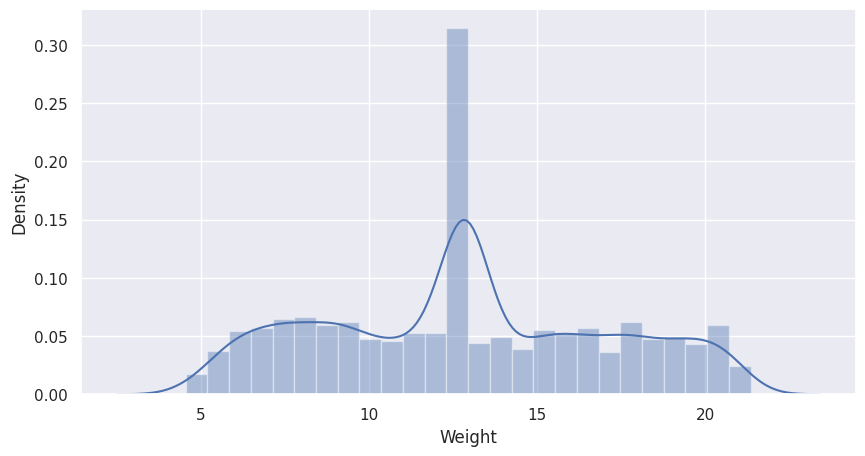

In [314]:
plt.figure(figsize=(10,5))
sns.distplot(data['Weight'])
plt.show()

/tmp/ipykernel_13095/373153471.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['ProductVisibility'])


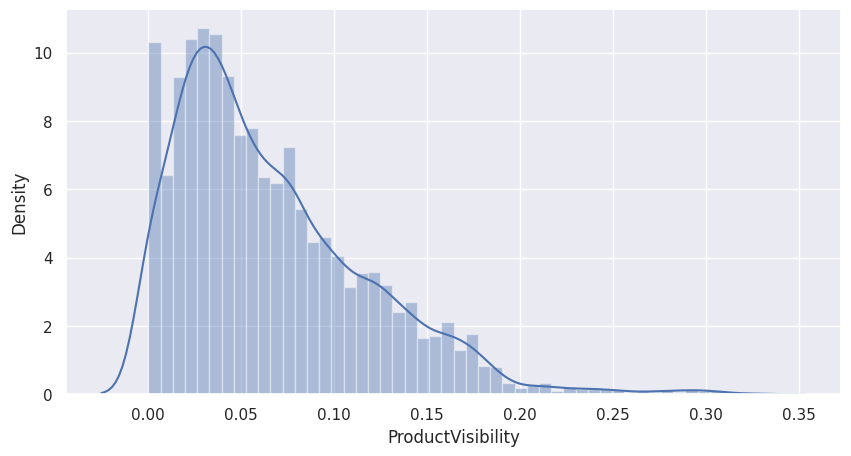

In [315]:
plt.figure(figsize=(10,5))
sns.distplot(data['ProductVisibility'])
plt.show()

/tmp/ipykernel_13095/99694374.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['MRP'])


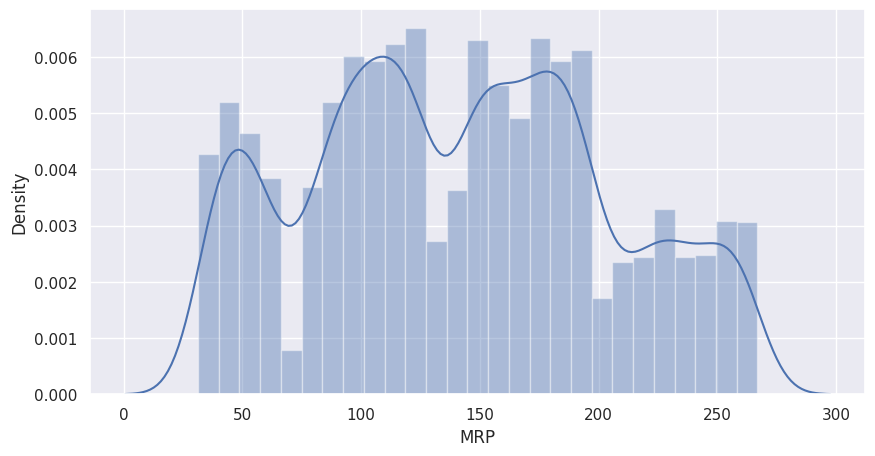

In [316]:
plt.figure(figsize=(10,5))
sns.distplot(data['MRP'])
plt.show()

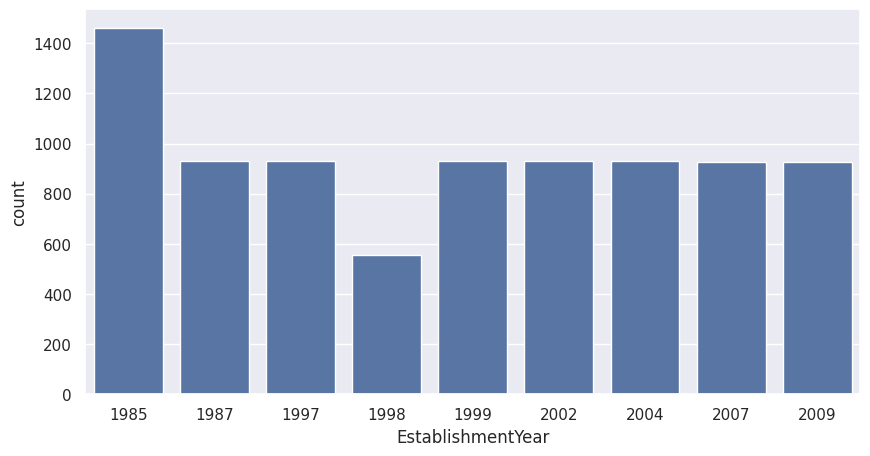

In [317]:
plt.figure(figsize=(10,5))
sns.countplot(x='EstablishmentYear',data=data)
plt.show()

/tmp/ipykernel_13095/1422061678.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['OutletSales'])


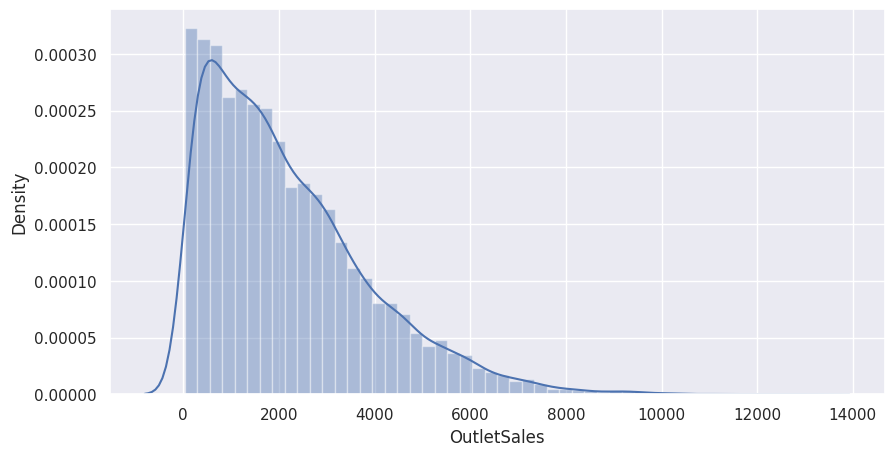

In [318]:
plt.figure(figsize=(10,5))
sns.distplot(data['OutletSales'])
plt.show()

# catagoriacal data


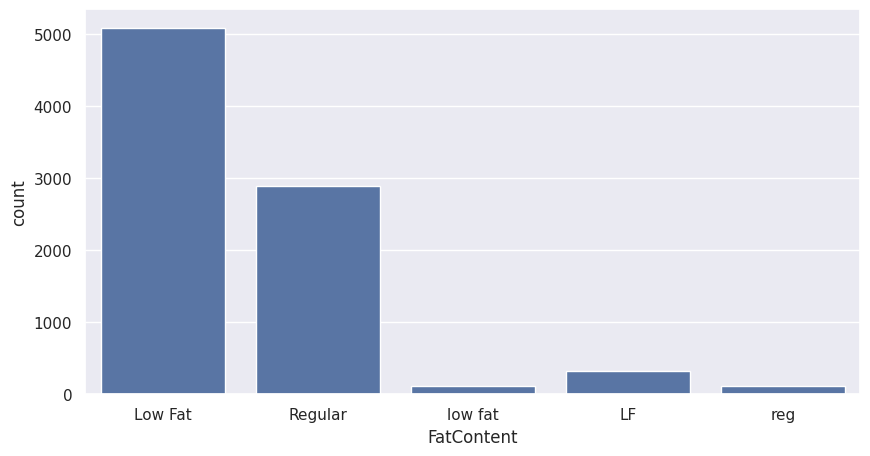

In [319]:
plt.figure(figsize=(10,5))
sns.countplot(x='FatContent',data=data)
plt.show()

In [320]:
data.replace({'FatContent': {'low fat':'Low Fat','LF':'Low Fat','reg':'Regular'}},inplace=True)

In [321]:
data['FatContent'].value_counts()

,count
FatContent,
Low Fat,5517
Regular,3006


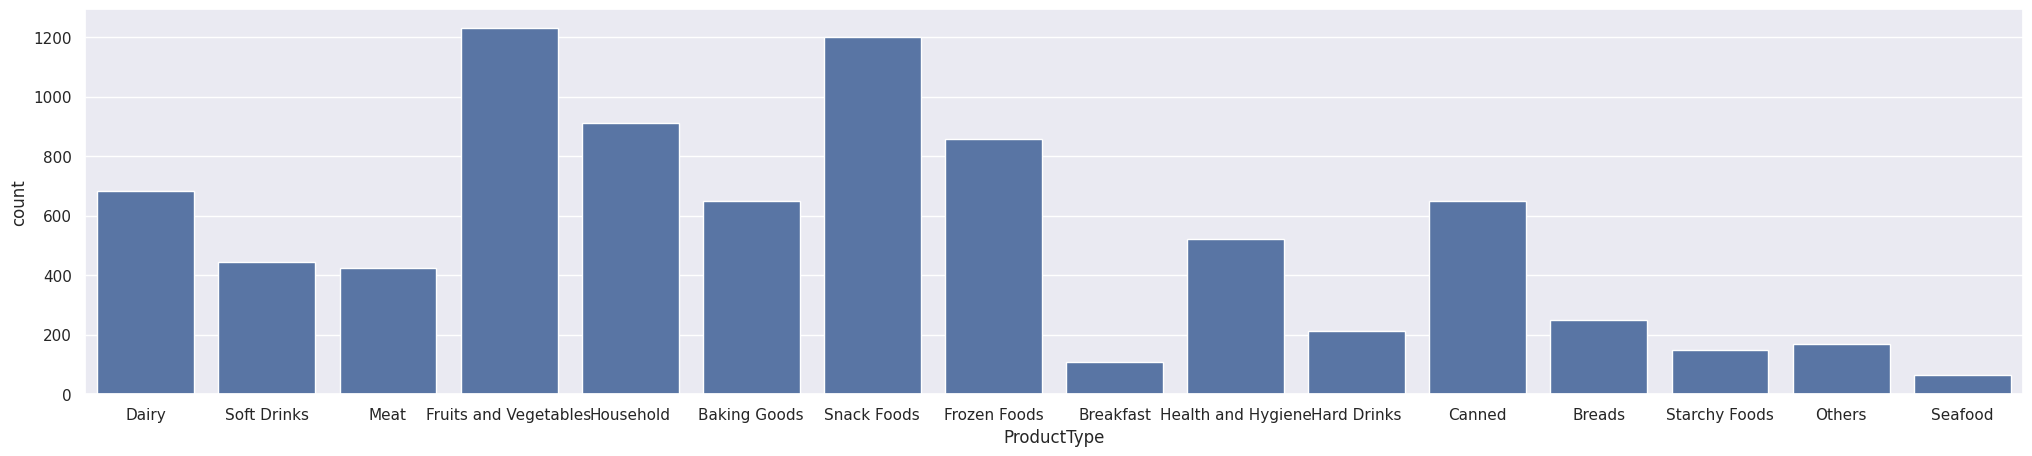

In [322]:
plt.figure(figsize=(25,5))
sns.countplot(x='ProductType',data=data)
plt.show()

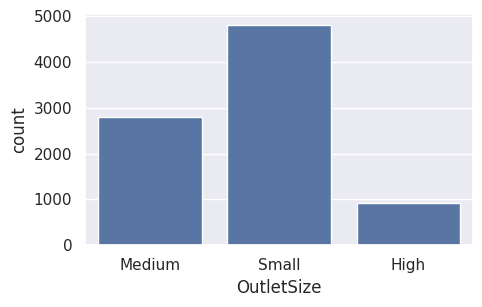

In [323]:
plt.figure(figsize=(5,3))
sns.countplot(x='OutletSize',data=data)
plt.show()

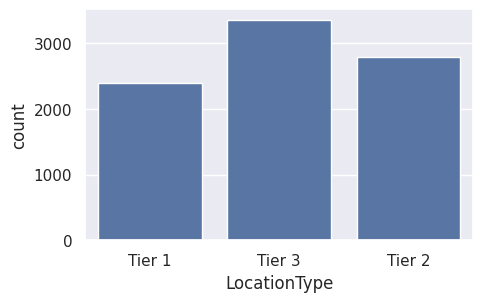

In [324]:
plt.figure(figsize=(5,3))
sns.countplot(x='LocationType',data=data)
plt.show()

In [325]:
encoder = LabelEncoder()

In [326]:
data['ProductType'] = encoder.fit_transform(data['ProductType'])
data['FatContent'] = encoder.fit_transform(data['FatContent'])
data['OutletSize'] = encoder.fit_transform(data['OutletSize'])
data['LocationType'] = encoder.fit_transform(data['LocationType'])
data['ProductID'] = encoder.fit_transform(data['ProductID'])
data['OutletID'] = encoder.fit_transform(data['OutletID'])
data['OutletType'] = encoder.fit_transform(data['OutletType'])

In [327]:
data.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


In [328]:
x= data.drop(columns=['OutletSales','ProductID'],axis=1)
y= data['OutletSales']

In [329]:
print(x)
print(y)

      Weight  FatContent  ProductVisibility  ProductType       MRP  OutletID  \
0      9.300           0           0.016047            4  249.8092         9   
1      5.920           1           0.019278           14   48.2692         3   
2     17.500           0           0.016760           10  141.6180         9   
3     19.200           1           0.000000            6  182.0950         0   
4      8.930           0           0.000000            9   53.8614         1   
...      ...         ...                ...          ...       ...       ...   
8518   6.865           0           0.056783           13  214.5218         1   
8519   8.380           1           0.046982            0  108.1570         7   
8520  10.600           0           0.035186            8   85.1224         6   
8521   7.210           1           0.145221           13  103.1332         3   
8522  14.800           0           0.044878           14   75.4670         8   

      EstablishmentYear  OutletSize  Lo

In [330]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=3)

In [331]:
model = XGBRegressor(
    n_estimators=250,
    learning_rate=0.04,
    max_depth=4,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=1,
    reg_lambda=2,
    random_state=42)
model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.04, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=250,
             n_jobs=None, num_parallel_tree=None, ...)

In [332]:
train_predict = model.predict(x_train)
train_result = metrics.r2_score(y_train,train_predict)
print(train_result)

0.6503417058900075


In [333]:
test_predict = model.predict(x_test)
test_result = metrics.r2_score(y_test,test_predict)
print(test_result)


0.626084640095798
